# 1. Load Dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [110]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.metrics import precision_recall_curve

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


In [3]:
filepath = '/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

churn = pd.read_csv(filepath)

churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
churn.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# 2. EDA

In [7]:
churn['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
churn['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [9]:
contract_churn = churn.groupby('Contract')['Churn'].value_counts(normalize=True)

In [10]:
churn.groupby('Contract')['Churn'].agg(['count']) / churn['Churn'].agg(['count'])

,count
Contract,
Month-to-month,0.550192
One year,0.209144
Two year,0.240664


In [11]:
contract_churn_rate = contract_churn.xs("Yes", level="Churn") * 100
print(contract_churn_rate)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: proportion, dtype: float64


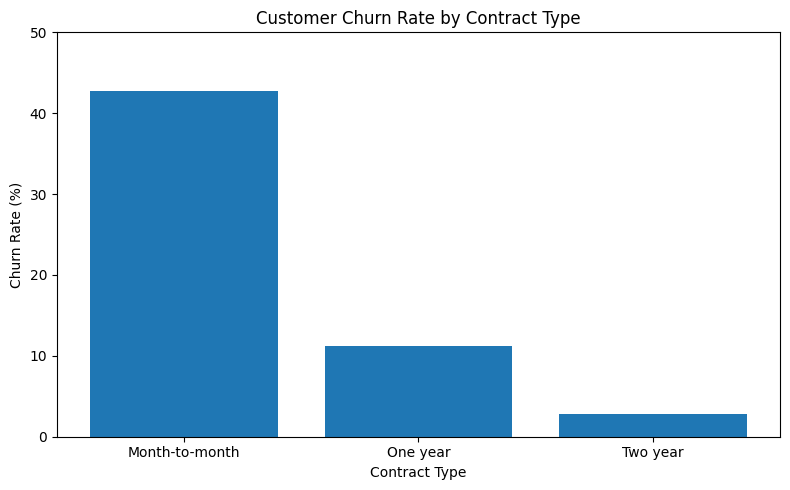

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    contract_churn_rate.index,
    contract_churn_rate.values
)

ax.set_title("Customer Churn Rate by Contract Type")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Churn Rate (%)")

ax.set_ylim(0, 50)

plt.tight_layout()
plt.show()

In [13]:
churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [14]:
total_numeric = pd.to_numeric(churn["TotalCharges"], errors="coerce")
print(total_numeric)

churn[total_numeric.isna()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [15]:
# TotalCharges contains 11 blank strings, all belonging to customers
# with tenure = 0. Convert the column to numeric and assign these
# new customers TotalCharges = 0.

churn["TotalCharges"] = pd.to_numeric(
    churn["TotalCharges"],
    errors="coerce"
)

churn["TotalCharges"] = churn["TotalCharges"].fillna(0)

In [16]:
churn.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


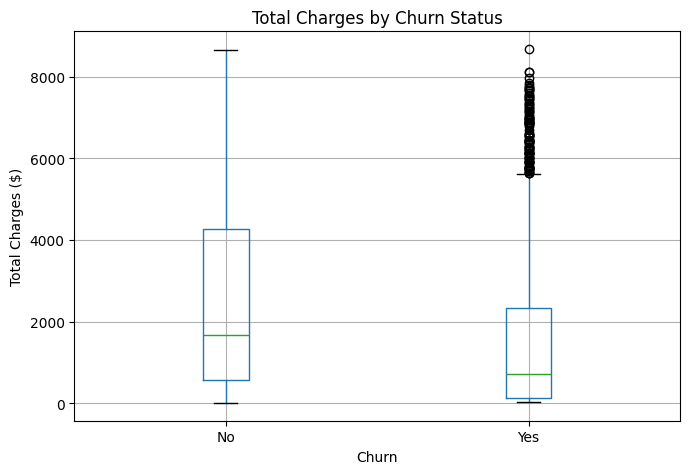

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

churn.boxplot(
    column="TotalCharges",
    by="Churn",
    ax=ax
)

ax.set_title("Total Charges by Churn Status")
ax.set_xlabel("Churn")
ax.set_ylabel("Total Charges ($)")

fig.suptitle("")

plt.tight_layout()
plt.show()

In [18]:
churn[["tenure", "MonthlyCharges", "TotalCharges"]].head(10)

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
5,8,99.65,820.50
6,22,89.10,1949.40
7,10,29.75,301.90
8,28,104.80,3046.05
9,62,56.15,3487.95


TotalCharges is a summation of the total amount someone has paid overtime 

In [19]:
churn.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


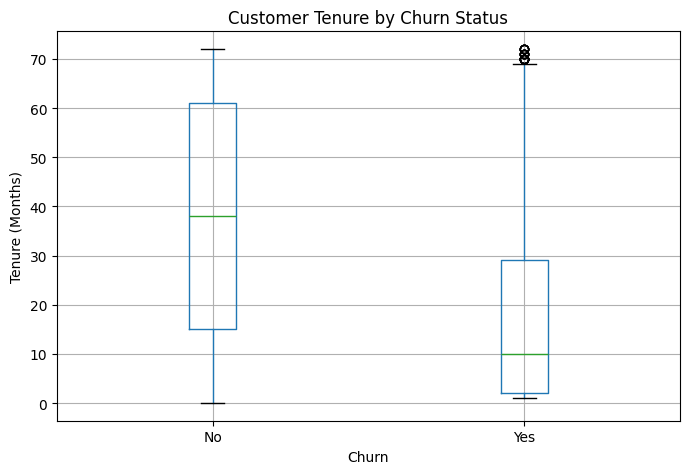

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

churn.boxplot(
    column="tenure",
    by="Churn",
    ax=ax
)

ax.set_title("Customer Tenure by Churn Status")
ax.set_xlabel("Churn")
ax.set_ylabel("Tenure (Months)")

fig.suptitle("")

plt.tight_layout()
plt.show()

In [21]:
# Divide Tenure into ranges
bins = [0, 6, 12, 24, 48, 72]

labels = [
    "0-6 months",
    "7-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

churn['TenureGroup'] = pd.cut(
    churn['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [22]:
churn[["tenure", "TenureGroup"]].head(20)

,tenure,TenureGroup
0,1,0-6 months
1,34,25-48 months
2,2,0-6 months
3,45,25-48 months
4,2,0-6 months
5,8,7-12 months
6,22,13-24 months
7,10,7-12 months
8,28,25-48 months
9,62,49-72 months


In [23]:
churn["TenureGroup"].value_counts(sort=False)


TenureGroup
0-6 months      1481
7-12 months      705
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

In [24]:
tenuregroup_churn = churn.groupby('TenureGroup')['Churn'].value_counts(normalize=True)

tenuregroup_churn

/tmp/ipykernel_58/646880519.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenuregroup_churn = churn.groupby('TenureGroup')['Churn'].value_counts(normalize=True)


TenureGroup   Churn
0-6 months    Yes      0.529372
              No       0.470628
7-12 months   No       0.641135
              Yes      0.358865
13-24 months  No       0.712891
              Yes      0.287109
25-48 months  No       0.796110
              Yes      0.203890
49-72 months  No       0.904868
              Yes      0.095132
Name: proportion, dtype: float64

In [25]:
tenure_churn_rate = tenuregroup_churn.xs("Yes", level="Churn") * 100

tenure_churn_rate

TenureGroup
0-6 months      52.937205
7-12 months     35.886525
13-24 months    28.710938
25-48 months    20.388959
49-72 months     9.513176
Name: proportion, dtype: float64

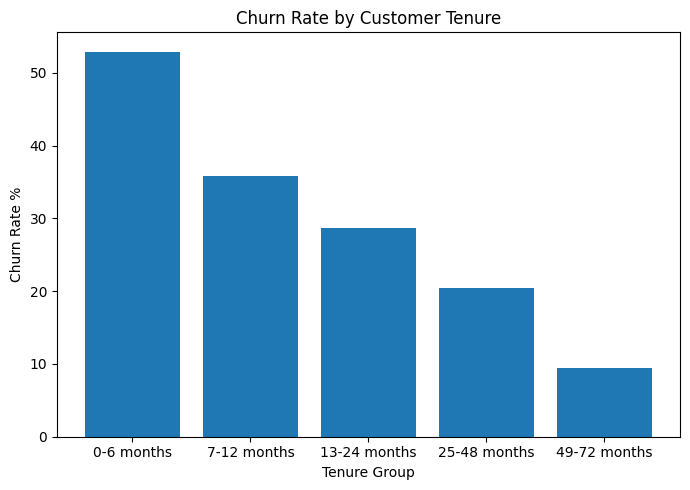

In [26]:
fig, ax = plt.subplots(figsize=(7,5))

ax.bar(
    tenure_churn_rate.index,
    tenure_churn_rate.values
)

ax.set_title('Churn Rate by Customer Tenure')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate %')

plt.tight_layout()
plt.show()

In [27]:
churn.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [28]:
churn.groupby("Churn")["MonthlyCharges"].agg(['mean', 'median'])

,mean,median
Churn,,
No,61.265124,64.425
Yes,74.441332,79.650


In [29]:
churn["MonthlyCharges"].min(), churn["MonthlyCharges"].max()

(18.25, 118.75)

In [30]:
churn["MonthlyChargeGroup"] = pd.cut(
    churn["MonthlyCharges"],
    bins=[0, 25, 50, 75, 100, 125],
    labels=[
        "$0-25",
        "$25-50",
        "$50-75",
        "$75-100",
        "$100-125"
    ]
)

churn["MonthlyChargeGroup"].value_counts(sort=False)

MonthlyChargeGroup
$0-25       1406
$25-50       893
$50-75      1624
$75-100     2218
$100-125     902
Name: count, dtype: int64

In [31]:
monthlygroup_churn = churn.groupby('MonthlyChargeGroup')['Churn'].value_counts(normalize=True)

monthlygroup_churn

/tmp/ipykernel_58/4001373021.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthlygroup_churn = churn.groupby('MonthlyChargeGroup')['Churn'].value_counts(normalize=True)


MonthlyChargeGroup  Churn
$0-25               No       0.909673
                    Yes      0.090327
$25-50              No       0.737962
                    Yes      0.262038
$50-75              No       0.737069
                    Yes      0.262931
$75-100             No       0.626691
                    Yes      0.373309
$100-125            No       0.719512
                    Yes      0.280488
Name: proportion, dtype: float64

In [32]:
churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroup', 'MonthlyChargeGroup'],
      dtype='object')

In [33]:
churn.groupby("InternetService")["Churn"].value_counts(normalize=True) * 100

InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.595020
                 Yes       7.404980
Name: proportion, dtype: float64

In [34]:
churn.groupby('MonthlyChargeGroup')['InternetService'].value_counts(normalize=True) * 100

/tmp/ipykernel_58/1070782257.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn.groupby('MonthlyChargeGroup')['InternetService'].value_counts(normalize=True) * 100


MonthlyChargeGroup  InternetService
$0-25               No                  97.083926
                    DSL                  2.916074
                    Fiber optic          0.000000
$25-50              DSL                 81.970885
                    No                  18.029115
                    Fiber optic          0.000000
$50-75              DSL                 75.000000
                    Fiber optic         25.000000
                    No                   0.000000
$75-100             Fiber optic         80.613165
                    DSL                 19.386835
                    No                   0.000000
$100-125            Fiber optic        100.000000
                    DSL                  0.000000
                    No                   0.000000
Name: proportion, dtype: float64

In [35]:
churngroups = churn.groupby(["InternetService", "Contract"])['Churn'].value_counts(normalize=True)
churngroups

InternetService  Contract        Churn
DSL              Month-to-month  No       0.677841
                                 Yes      0.322159
                 One year        No       0.907018
                                 Yes      0.092982
                 Two year        No       0.980892
                                 Yes      0.019108
Fiber optic      Month-to-month  Yes      0.546053
                                 No       0.453947
                 One year        No       0.807050
                                 Yes      0.192950
                 Two year        No       0.927739
                                 Yes      0.072261
No               Month-to-month  No       0.811069
                                 Yes      0.188931
                 One year        No       0.975275
                                 Yes      0.024725
                 Two year        No       0.992163
                                 Yes      0.007837
Name: proportion, dtype: float64

In [36]:
churn_internet_contract = churngroups.xs('Yes', level='Churn') * 100
churn_internet_contract

InternetService  Contract      
DSL              Month-to-month    32.215863
                 One year           9.298246
                 Two year           1.910828
Fiber optic      Month-to-month    54.605263
                 One year          19.294991
                 Two year           7.226107
No               Month-to-month    18.893130
                 One year           2.472527
                 Two year           0.783699
Name: proportion, dtype: float64

In [37]:
fiber_monthly = churn[
    (churn['InternetService'] == 'Fiber optic') &
    (churn['Contract'] == 'Month-to-month')
]

fiber_monthly

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyChargeGroup
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6 months,$50-75
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,7-12 months,$75-100
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,13-24 months,$75-100
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,25-48 months,$100-125
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,49-72 months,$100-125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,0-6 months,$75-100
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No,25-48 months,$50-75
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,49-72 months,$100-125
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.10,No,13-24 months,$75-100


In [38]:
fiber_monthly["tenure"].describe()

count    2128.000000
mean       21.554981
std        18.941719
min         1.000000
25%         5.000000
50%        16.000000
75%        34.000000
max        72.000000
Name: tenure, dtype: float64

In [39]:
fiber_monthly.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,966.0,27.905797,19.606767,1.0,11.0,24.5,43.0,72.0
Yes,1162.0,16.275387,16.623248,1.0,3.0,10.0,25.0,71.0


In [40]:
fiber_month_tenure = fiber_monthly.groupby("TenureGroup")["Churn"].value_counts(normalize=True)
fiber_month_tenure

/tmp/ipykernel_58/3158870427.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fiber_month_tenure = fiber_monthly.groupby("TenureGroup")["Churn"].value_counts(normalize=True)


TenureGroup   Churn
0-6 months    Yes      0.741519
              No       0.258481
7-12 months   Yes      0.619529
              No       0.380471
13-24 months  Yes      0.505882
              No       0.494118
25-48 months  No       0.566219
              Yes      0.433781
49-72 months  No       0.706767
              Yes      0.293233
Name: proportion, dtype: float64

In [41]:
fiber_month_tenure.xs('Yes',level='Churn')

TenureGroup
0-6 months      0.741519
7-12 months     0.619529
13-24 months    0.505882
25-48 months    0.433781
49-72 months    0.293233
Name: proportion, dtype: float64

Among fiber-optic customers on month-to-month contracts, churn was highest among newer customers and declined steadily with tenure. However, elevated churn persisted even among long-tenure customers, suggesting that the subgroup's churn pattern is not explained by tenure alone.

In [42]:
churn.groupby("TechSupport")["Churn"].value_counts(normalize=True)

TechSupport          Churn
No                   No       0.583645
                     Yes      0.416355
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.848337
                     Yes      0.151663
Name: proportion, dtype: float64

In [43]:
churn.groupby(["TechSupport",'InternetService'])["Churn"].value_counts(normalize=True)

TechSupport          InternetService  Churn
No                   DSL              No       0.722446
                                      Yes      0.277554
                     Fiber optic      No       0.506278
                                      Yes      0.493722
No internet service  No               No       0.925950
                                      Yes      0.074050
Yes                  DSL              No       0.903226
                                      Yes      0.096774
                     Fiber optic      No       0.773672
                                      Yes      0.226328
Name: proportion, dtype: float64

In [44]:
churn.groupby("OnlineSecurity")["Churn"].value_counts(normalize=True)

OnlineSecurity       Churn
No                   No       0.582333
                     Yes      0.417667
No internet service  No       0.925950
                     Yes      0.074050
Yes                  No       0.853888
                     Yes      0.146112
Name: proportion, dtype: float64

In [45]:
pd.crosstab(
    churn["TechSupport"],
    churn["OnlineSecurity"]
)

OnlineSecurity,No,No internet service,Yes
TechSupport,,,
No,2553,0,920
No internet service,0,1526,0
Yes,945,0,1099


In [46]:
pd.crosstab(
    churn["TechSupport"],
    churn["OnlineSecurity"],
    normalize="index"
) * 100

OnlineSecurity,No,No internet service,Yes
TechSupport,,,
No,73.509934,0.0,26.490066
No internet service,0.000000,100.0,0.000000
Yes,46.232877,0.0,53.767123


In [47]:
churn.groupby("PaymentMethod")["Churn"].value_counts(normalize=True)

PaymentMethod              Churn
Bank transfer (automatic)  No       0.832902
                           Yes      0.167098
Credit card (automatic)    No       0.847569
                           Yes      0.152431
Electronic check           No       0.547146
                           Yes      0.452854
Mailed check               No       0.808933
                           Yes      0.191067
Name: proportion, dtype: float64

In [48]:
churn.groupby("PaperlessBilling")["Churn"].value_counts(normalize=True)

PaperlessBilling  Churn
No                No       0.836699
                  Yes      0.163301
Yes               No       0.664349
                  Yes      0.335651
Name: proportion, dtype: float64

In [49]:
pd.crosstab(
    churn["PaperlessBilling"],
    churn["PaymentMethod"],
    normalize="index"
) * 100

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
PaperlessBilling,,,,
No,22.736769,22.284123,21.692201,33.286908
Yes,21.361784,21.146008,41.764565,15.727643


In [50]:
churn.groupby(['PaymentMethod', 'PaperlessBilling'])['Churn'].value_counts(normalize=True)

PaymentMethod              PaperlessBilling  Churn
Bank transfer (automatic)  No                No       0.889740
                                             Yes      0.110260
                           Yes               No       0.791246
                                             Yes      0.208754
Credit card (automatic)    No                No       0.900000
                                             Yes      0.100000
                           Yes               No       0.809524
                                             Yes      0.190476
Electronic check           No                No       0.672552
                                             Yes      0.327448
                           Yes               No       0.502296
                                             Yes      0.497704
Mailed check               No                No       0.865063
                                             Yes      0.134937
                           Yes               No       0.727134
    

### EDA Findings

Churn rates were highest among customers with shorter tenure, particularly those in the 0–6 month range. Higher churn rates were also observed among customers with fiber-optic internet, month-to-month contracts, and no technical support. Customers without online security also showed higher churn rates. Electronic check users had substantially higher churn than customers using other payment methods, and customers using both electronic checks and paperless billing showed particularly high churn. These relationships are associations within the dataset and do not establish that these features cause customers to churn.

# 3. Preprocessing

In [51]:
churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroup', 'MonthlyChargeGroup'],
      dtype='object')

In [52]:
X = churn.drop(columns=["customerID", "Churn"])
y = churn["Churn"]

In [53]:
X.dtypes

gender                  object
SeniorCitizen            int64
Partner                 object
Dependents              object
tenure                   int64
PhoneService            object
MultipleLines           object
InternetService         object
OnlineSecurity          object
OnlineBackup            object
DeviceProtection        object
TechSupport             object
StreamingTV             object
StreamingMovies         object
Contract                object
PaperlessBilling        object
PaymentMethod           object
MonthlyCharges         float64
TotalCharges           float64
TenureGroup           category
MonthlyChargeGroup    category
dtype: object

In [54]:
X = churn.drop(
    columns=[
        "customerID",
        "Churn",
        "TenureGroup",
        "MonthlyChargeGroup"
    ]
)

In [55]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)

In [57]:
y_train.value_counts(normalize=True)

Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64

In [58]:
y_test.value_counts(normalize=True)

Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64

# 4. Modeling

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

In [60]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor ),
        ('classifier', LogisticRegression())
    ]
)

In [61]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', LogisticRegression())])

In [62]:
y_pred = model.predict(X_test)

In [63]:
y_pred[:10]

array(['No', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No'],
      dtype=object)

In [64]:
cm = confusion_matrix(y_test, y_pred, labels=["No", "Yes"])
cm

array([[926, 109],
       [165, 209]])

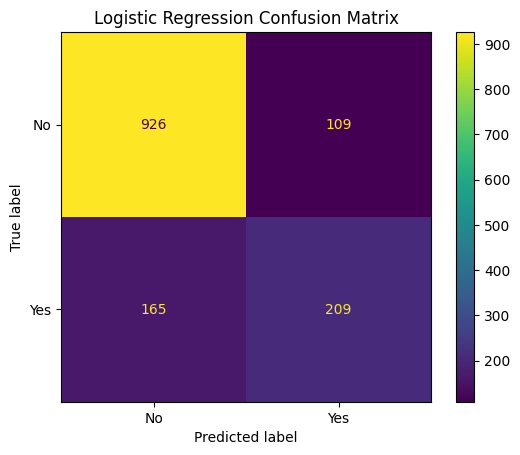

In [65]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No", "Yes"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [66]:
y_prob = model.predict_proba(X_test)
y_prob[:5]

array([[0.95408007, 0.04591993],
       [0.31628655, 0.68371345],
       [0.94106015, 0.05893985],
       [0.59816471, 0.40183529],
       [0.97857574, 0.02142426]])

In [67]:
y_prob = model.predict_proba(X_test)[:, 1]
y_prob

array([0.04591993, 0.68371345, 0.05893985, ..., 0.15442215, 0.00428645,
       0.00628801])

In [68]:
y_pred_30 = y_prob >= 0.30

In [69]:
y_pred_30 = np.where(y_prob >= 0.30, "Yes", "No")

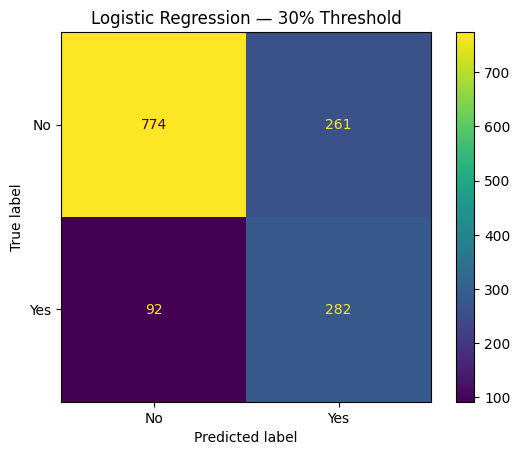

In [70]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_30,
    display_labels=["No", "Yes"]
)

plt.title("Logistic Regression — 30% Threshold")
plt.show()

In [71]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test, y_pred, pos_label="Yes"
)

recall = recall_score(
    y_test, y_pred, pos_label="Yes"
)

f1 = f1_score(
    y_test, y_pred, pos_label="Yes"
)

In [72]:
y_test_binary = (y_test == "Yes").astype(int)

roc_auc = roc_auc_score(
    y_test_binary,
    y_prob
)

pr_auc = average_precision_score(
    y_test_binary,
    y_prob
)

In [73]:
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")
print(f"PR-AUC:    {pr_auc:.3f}")

Accuracy:  0.806
Precision: 0.657
Recall:    0.559
F1:        0.604
ROC-AUC:   0.842
PR-AUC:    0.634


In [74]:
precision_values, recall_values, thresholds = precision_recall_curve(
    y_test_binary,
    y_prob
)

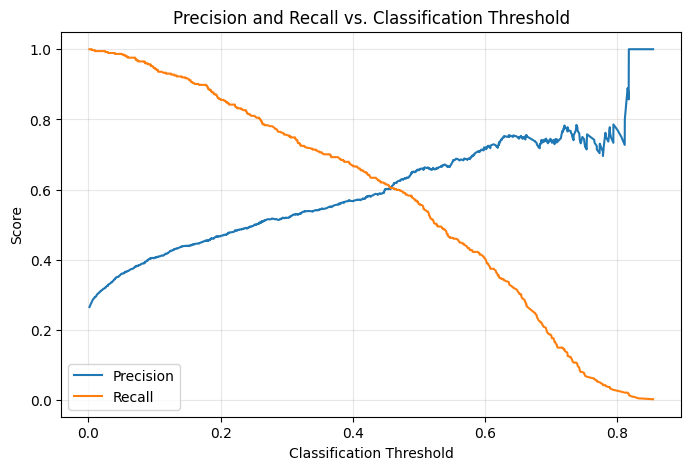

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, precision_values[:-1], label="Precision")
plt.plot(thresholds, recall_values[:-1], label="Recall")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [76]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42
        ))
    ]
)

In [77]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [78]:
cm_rf = confusion_matrix(y_test, rf_pred, labels=["No", "Yes"])
cm_rf

array([[926, 109],
       [192, 182]])

In [79]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [80]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test, rf_pred, pos_label="Yes"
)

rf_recall = recall_score(
    y_test, rf_pred, pos_label="Yes"
)

rf_f1 = f1_score(
    y_test, rf_pred, pos_label="Yes"
)

rf_roc_auc = roc_auc_score(
    y_test_binary,
    rf_prob
)

rf_pr_auc = average_precision_score(
    y_test_binary,
    rf_prob
)

print(f"Accuracy:  {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall:    {rf_recall:.3f}")
print(f"F1:        {rf_f1:.3f}")
print(f"ROC-AUC:   {rf_roc_auc:.3f}")
print(f"PR-AUC:    {rf_pr_auc:.3f}")

Accuracy:  0.786
Precision: 0.625
Recall:    0.487
F1:        0.547
ROC-AUC:   0.819
PR-AUC:    0.611


In [81]:
from xgboost import XGBClassifier

y_train_binary = (y_train == "Yes").astype(int)
y_test_binary = (y_test == "Yes").astype(int)

In [82]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            random_state=42
        ))
    ]
)

In [83]:
xgb_model.fit(X_train, y_train_binary)

xgb_pred = xgb_model.predict(X_test)

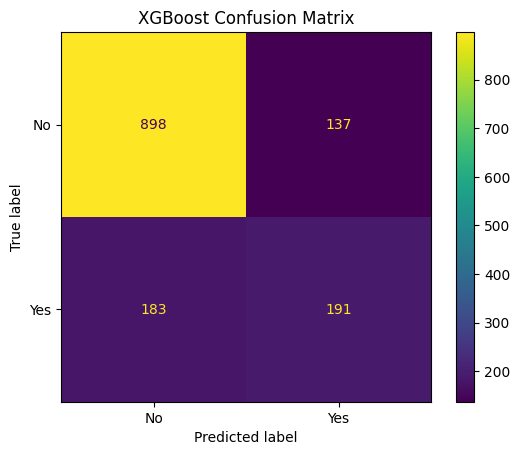

In [84]:
ConfusionMatrixDisplay.from_predictions(
    y_test_binary,
    xgb_pred,
    display_labels=["No", "Yes"]
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [85]:
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_prob

array([6.8367372e-04, 9.2546558e-01, 1.3574357e-01, ..., 8.5880049e-02,
       4.3646336e-02, 8.2101492e-04], dtype=float32)

In [86]:
xgb_accuracy = accuracy_score(y_test_binary, xgb_pred)
xgb_precision = precision_score(y_test_binary, xgb_pred)
xgb_recall = recall_score(y_test_binary, xgb_pred)
xgb_f1 = f1_score(y_test_binary, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test_binary, xgb_prob)
xgb_pr_auc = average_precision_score(y_test_binary, xgb_prob)

print(f"Accuracy:  {xgb_accuracy:.3f}")
print(f"Precision: {xgb_precision:.3f}")
print(f"Recall:    {xgb_recall:.3f}")
print(f"F1:        {xgb_f1:.3f}")
print(f"ROC-AUC:   {xgb_roc_auc:.3f}")
print(f"PR-AUC:    {xgb_pr_auc:.3f}")

Accuracy:  0.773
Precision: 0.582
Recall:    0.511
F1:        0.544
ROC-AUC:   0.815
PR-AUC:    0.603


### CV Models

In [87]:
#Cleaning up tree processor
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [88]:
#Updating pipelines
log_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("classifier", LogisticRegression())
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

xgb_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", XGBClassifier(random_state=42))
    ]
)

In [90]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [92]:
# Logistic Regression
scores = cross_val_score(
    log_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

In [94]:
print(scores)
print(scores.mean())
print(scores.std())

[0.84791899 0.82518015 0.84191669 0.86296714 0.85302075]
0.8462007441910661
0.012576130140361557


In [95]:
# Random Forest
rf_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

In [96]:
print(rf_scores)
print(rf_scores.mean())
print(rf_scores.std())

[0.80925953 0.80167588 0.82330393 0.81648369 0.83778051]
0.8177007063580943
0.012362235991024987


In [97]:
#XGBoost
xgb_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train_binary,
    cv=cv,
    scoring="roc_auc"
)

In [98]:
print(xgb_scores)
print(xgb_scores.mean())
print(xgb_scores.std())

[0.81811554 0.8091121  0.82440058 0.83396345 0.82790074]
0.8226984815097381
0.008514146434076525


### Regularization

In [100]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator = log_model,
    param_grid = param_grid,
    cv = cv,
    scoring = "roc_auc"
)

In [101]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier', LogisticRegression())]),
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100]},
             scoring='roc_auc')

In [102]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'classifier__C': 10}
0.8463914680855682


Five-fold cross-validation selected C=10, although performance was nearly identical to the default model, indicating that Logistic Regression was relatively insensitive to regularization strength over the tested range.

In [105]:
results = pd.DataFrame(grid_search.cv_results_)

results[
    ["param_classifier__C", "mean_test_score", "std_test_score"]
]

,param_classifier__C,mean_test_score,std_test_score
0,0.01,0.843468,0.010933
1,0.10,0.845486,0.011968
2,1.00,0.846201,0.012576
3,10.00,0.846391,0.012827
4,100.00,0.846327,0.012941


In [106]:
rf_param_grid = {
    "classifier__n_estimators": [100, 300, 500],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10]
}

rf_grid_search = GridSearchCV(
    estimator = rf_model,
    param_grid = rf_param_grid,
    cv = cv,
    scoring = "roc_auc"
)

rf_grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService',...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 5, 10, 20],
                         'classifier__min_samples_leaf': [1, 2, 5, 10],
                         'classifier__n_estimators': [100, 300, 500]},
             scoring='roc_auc')

In [107]:
print(rf_grid_search.best_params_)
print(rf_grid_search.best_score_)

{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 300}
0.847875628319897


In [108]:
rf_results = pd.DataFrame(rf_grid_search.cv_results_)

rf_results.loc[
    rf_results["rank_test_score"] <= 10,
    [
        "param_classifier__n_estimators",
        "param_classifier__max_depth",
        "param_classifier__min_samples_leaf",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
34,300,10,10,0.847876,0.009084,1
35,500,10,10,0.847688,0.009173,2
33,100,10,10,0.847462,0.008564,3
11,500,None,10,0.847306,0.009104,4
47,500,20,10,0.847306,0.009104,4
10,300,None,10,0.847191,0.009279,6
46,300,20,10,0.847191,0.009279,6
9,100,None,10,0.846892,0.009190,8
45,100,20,10,0.846892,0.009190,8
30,100,10,5,0.846589,0.008908,10


In [109]:
xgb_param_dist = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "classifier__max_depth": [2, 3, 4, 5, 6],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [111]:
xgb_random_search = RandomizedSearchCV(
    estimator = xgb_model,
    param_distributions = xgb_param_dist,
    n_iter = 40,
    cv=cv,
    scoring = "roc_auc",
    random_state = 42,
    n_jobs = -1
)

xgb_random_search.fit(X_train, y_train_binary)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               Index(['gender', 'Partner', 'Dependents', 'PhoneSer...
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.7,
                                                                         0.8,
                                                                         0.9,
                                                                         1.0],
                                        'classifier__learning_rate': [0.01,
                                                                      0.03,
                                                                      0.05, 0.1,
                                                                      0.2],
                                        'classifier__max_depth': [2, 3, 4, 5,
                                                                  6],
                                        'classifier__n_estimators': [100, 200,
                                                                     300, 500],
                                        'classifier__subsample': [0.7, 0.8, 0.9,
                                                                  1.0]},
                   random_state=42, scoring='roc_auc')

In [112]:
print(xgb_random_search.best_params_)
print(xgb_random_search.best_score_)

{'classifier__subsample': 0.8, 'classifier__n_estimators': 500, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.7}
0.8505923780852751


In [113]:
xgb_results = pd.DataFrame(xgb_random_search.cv_results_)

xgb_results.loc[
    xgb_results["rank_test_score"] <= 10,
    [
        "param_classifier__learning_rate",
        "param_classifier__n_estimators",
        "param_classifier__max_depth",
        "param_classifier__subsample",
        "param_classifier__colsample_bytree",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_classifier__learning_rate,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__subsample,param_classifier__colsample_bytree,mean_test_score,std_test_score,rank_test_score
24,0.01,500,3,0.8,0.7,0.850592,0.011480,1
16,0.01,500,3,0.9,0.7,0.850389,0.011621,2
21,0.03,200,2,0.8,0.8,0.849711,0.011618,3
17,0.03,300,3,0.7,0.9,0.849589,0.011352,4
10,0.03,100,4,0.9,0.8,0.849487,0.010391,5
2,0.05,300,2,0.7,0.7,0.849331,0.011298,6
12,0.05,300,2,0.7,0.9,0.848782,0.012107,7
6,0.01,200,5,0.8,1.0,0.848640,0.010297,8
3,0.03,200,5,1.0,0.7,0.848062,0.010539,9
15,0.01,100,6,0.8,0.7,0.847936,0.010890,10


XGBoost appears to perform better in this search when learning gradually with relatively shallow trees rather than making aggressive corrections with highly complex trees

### Test Models

In [114]:
best_log = grid_search.best_estimator_
best_rf = rf_grid_search.best_estimator_
best_xgb = xgb_random_search.best_estimator_

In [115]:
log_test_prob = grid_search.predict_proba(X_test)[:, 1]
rf_test_prob = rf_grid_search.predict_proba(X_test)[:, 1]
xgb_test_prob = xgb_random_search.predict_proba(X_test)[:, 1]

In [116]:
print("Logistic Regression")
print("ROC-AUC:", roc_auc_score(y_test_binary, log_test_prob))
print("PR-AUC: ", average_precision_score(y_test_binary, log_test_prob))

print("\nRandom Forest")
print("ROC-AUC:", roc_auc_score(y_test_binary, rf_test_prob))
print("PR-AUC: ", average_precision_score(y_test_binary, rf_test_prob))

print("\nXGBoost")
print("ROC-AUC:", roc_auc_score(y_test_binary, xgb_test_prob))
print("PR-AUC: ", average_precision_score(y_test_binary, xgb_test_prob))

Logistic Regression
ROC-AUC: 0.8412384716732543
PR-AUC:  0.6281355522895387

Random Forest
ROC-AUC: 0.8436423054070112
PR-AUC:  0.6544560349288608

XGBoost
ROC-AUC: 0.8480185486579349
PR-AUC:  0.6653858119363322


Initial baseline testing favored Logistic Regression. However, cross-validated hyperparameter tuning substantially improved the tree-based models. The tuned XGBoost model achieved the strongest held-out ranking performance, with ROC-AUC of 0.848 and PR-AUC of 0.665.

In [117]:
risk_df = pd.DataFrame({
    "actual_churn": y_test_binary.to_numpy(),
    "predicted_risk": xgb_test_prob
})

risk_df.head()

,actual_churn,predicted_risk
0,0,0.041141
1,0,0.739115
2,0,0.064493
3,0,0.319736
4,0,0.023770


In [118]:
risk_df = risk_df.sort_values(
    by="predicted_risk",
    ascending=False
)

In [120]:
risk_df.head(10)

,actual_churn,predicted_risk
1090,1,0.893446
1109,1,0.881767
1221,1,0.880256
618,1,0.862630
1259,1,0.848172
1175,1,0.847866
647,1,0.846481
344,1,0.844240
83,1,0.836591
1164,1,0.835585


In [121]:
top_200 = risk_df[:200]
top_200["actual_churn"].sum()

np.int64(146)

In [122]:
precision_at_200 = top_200["actual_churn"].mean()

print(precision_at_200)

0.73


In [123]:
k = 200

top_k = risk_df.head(k)

precision_at_k = top_k["actual_churn"].mean()
recall_at_k = top_k["actual_churn"].sum() / risk_df["actual_churn"].sum()

print(f"Precision@{k}: {precision_at_k:.3f}")
print(f"Recall@{k}: {recall_at_k:.3f}")

Precision@200: 0.730
Recall@200: 0.390


In [124]:
ks = [50, 100, 200, 300, 500]

for k in ks:
    top_k = risk_df.head(k)

    precision_at_k = top_k["actual_churn"].mean()
    recall_at_k = (
        top_k["actual_churn"].sum()
        / risk_df["actual_churn"].sum()
    )

    print(f"K = {k}")
    print(f"Precision@{k}: {precision_at_k:.3f}")
    print(f"Recall@{k}: {recall_at_k:.3f}")
    print()

K = 50
Precision@50: 0.840
Recall@50: 0.112

K = 100
Precision@100: 0.780
Recall@100: 0.209

K = 200
Precision@200: 0.730
Recall@200: 0.390

K = 300
Precision@300: 0.673
Recall@300: 0.540

K = 500
Precision@500: 0.562
Recall@500: 0.751



In [126]:
overall_churn_rate = risk_df["actual_churn"].mean()

In [129]:
# Lift tells us how much better our model's targeting is than selecting customers without the model
overall_churn_rate = risk_df["actual_churn"].mean()

ks = [50, 100, 200, 300, 500]
results = []

for k in ks:
    top_k = risk_df.head(k)

    precision_at_k = top_k["actual_churn"].mean()

    recall_at_k = (
        top_k["actual_churn"].sum()
        / risk_df["actual_churn"].sum()
    )

    lift_at_k = precision_at_k / overall_churn_rate

    results.append({
        "K": k,
        "Precision@K": precision_at_k,
        "Recall@K": recall_at_k,
        "Lift@K": lift_at_k
    })

results_df = pd.DataFrame(results)

results_df

,K,Precision@K,Recall@K,Lift@K
0,50,0.840000,0.112299,3.164599
1,100,0.780000,0.208556,2.938556
2,200,0.730000,0.390374,2.750187
3,300,0.673333,0.540107,2.536702
4,500,0.562000,0.751337,2.117267


# 5. Conclusion

### Conclusion
This analysis examined customer churn using demographic, account, service, billing, and payment information. Exploratory analysis identified several characteristics associated with higher churn, including shorter tenure, month-to-month contracts, fiber-optic internet service, lack of technical support or online security, electronic check payments, and paperless billing. These relationships represent associations within the dataset and should not be interpreted as causal effects.
Three classification approaches were evaluated: Logistic Regression, Random Forest, and XGBoost. Initial baseline results favored Logistic Regression, but cross-validated hyperparameter tuning substantially improved the tree-based models. The tuned XGBoost model achieved the strongest held-out ranking performance, with a ROC-AUC of 0.848 and PR-AUC of 0.665.
Rather than relying solely on a fixed classification threshold, predicted churn probabilities were used to rank customers by risk and simulate different retention-team capacities. The highest-risk segments were substantially enriched with actual churners. For example, the top 200 customers achieved 73.0% Precision@200, 39.0% Recall@200, and 2.75× Lift@200. Expanding outreach to the top 500 customers captured 75.1% of all churners, while maintaining 56.2% precision and 2.12× lift.
These results demonstrate how churn probabilities can be used as a prioritization tool: organizations with limited retention capacity can concentrate outreach among customers with the highest predicted risk, while larger outreach programs can trade some precision for greater churn coverage.

### Limitations
The dataset represents a historical customer snapshot rather than a longitudinal record of customer behavior. Consequently, the model estimates associations with churn but does not establish why customers churn or whether a particular retention intervention would prevent churn.
Additionally, the dataset does not contain customer lifetime value, retention-offer costs, contact costs, or evidence about intervention effectiveness. Therefore, the analysis cannot determine an economically optimal number of customers to contact. Precision@K, Recall@K, and Lift@K instead illustrate how model performance changes under different hypothetical outreach capacities.
Finally, a churn-risk model identifies customers likely to leave; it does not necessarily identify customers who are most persuadable. A production retention system could extend this analysis using intervention experiments, customer value estimates, and ultimately uplift modeling to identify customers whose behavior is most likely to change because of an intervention.